In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("New training shape:", X_train.shape)

New training shape: (60000, 784)


In [5]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

C:\Users\sauvi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8642 - loss: 0.4597 - val_accuracy: 0.9603 - val_loss: 0.1348
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9639 - loss: 0.1159 - val_accuracy: 0.9625 - val_loss: 0.1266
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9769 - loss: 0.0772 - val_accuracy: 0.9712 - val_loss: 0.0995
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9836 - loss: 0.0532 - val_accuracy: 0.9737 - val_loss: 0.0964
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9860 - loss: 0.0431 - val_accuracy: 0.9738 - val_loss: 0.0922
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9887 - loss: 0.0353 - val_accuracy: 0.9735 - val_loss: 0.0971
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9906 - loss: 0.0279 - val_accuracy: 0.9749 - val_loss: 0.0958
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9928 - loss: 0.0218 -

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9744 - loss: 0.1077
Test Loss: 0.09458363801240921
Test Accuracy: 0.9775000214576721


In [10]:
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]

In [11]:
from tensorflow.keras.optimizers import Adam

results = {}

for lr in learning_rates:
    for batch in batch_sizes:

        model = Sequential([
            Dense(128, activation='relu', input_shape=(784,)),
            Dense(64, activation='relu'),
            Dense(10, activation='softmax')
        ])

        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train,
            y_train_cat,
            epochs=5,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

        results[(lr, batch)] = test_acc

        print(f"Learning Rate: {lr}, Batch Size: {batch}, Test Accuracy: {test_acc}")

Learning Rate: 0.01, Batch Size: 32, Test Accuracy: 0.9616000056266785
Learning Rate: 0.01, Batch Size: 64, Test Accuracy: 0.9580000042915344
Learning Rate: 0.01, Batch Size: 128, Test Accuracy: 0.964900016784668
Learning Rate: 0.001, Batch Size: 32, Test Accuracy: 0.9753999710083008
Learning Rate: 0.001, Batch Size: 64, Test Accuracy: 0.9753999710083008
Learning Rate: 0.001, Batch Size: 128, Test Accuracy: 0.9718000292778015
Learning Rate: 0.0001, Batch Size: 32, Test Accuracy: 0.955299973487854
Learning Rate: 0.0001, Batch Size: 64, Test Accuracy: 0.9455000162124634
Learning Rate: 0.0001, Batch Size: 128, Test Accuracy: 0.9401000142097473


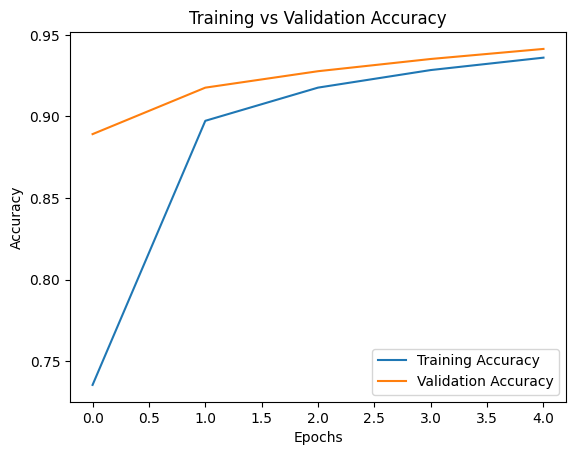

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


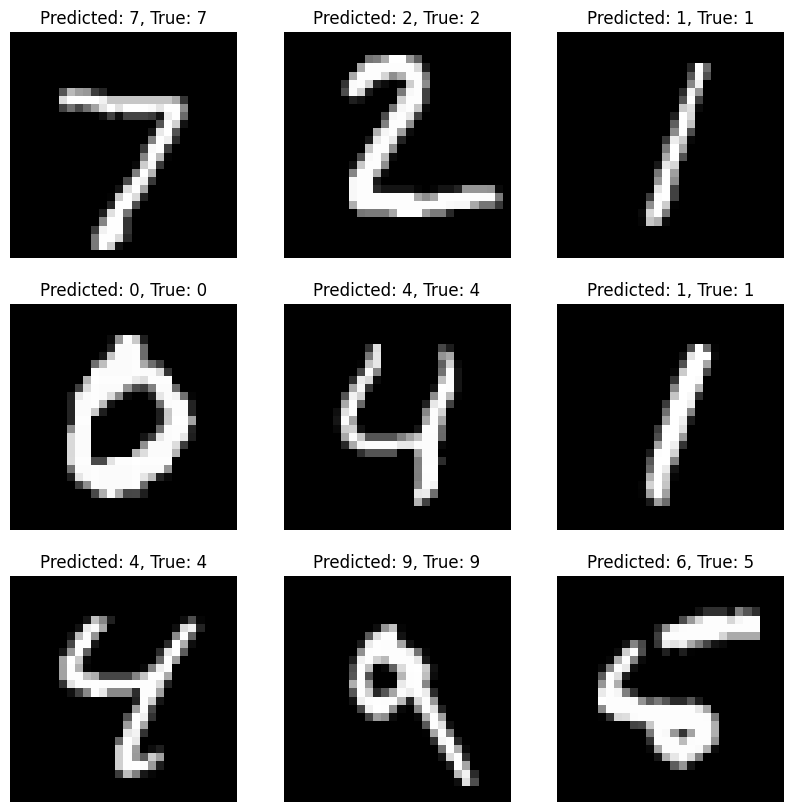

In [13]:
import numpy as np

predictions = model.predict(X_test)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    image = X_test[i].reshape(28,28)

    predicted_label = np.argmax(predictions[i])

    plt.imshow(image, cmap='gray')

    plt.title(f"Predicted: {predicted_label}, True: {y_test[i]}")

    plt.axis('off')

plt.show()